## **Principal Component Analysis**

### **Exercise 3**

In this exercise, we will use PCA to analyze the breast cancer dataset. We will start by
loading the data and handling missing values. Then, we will apply PCA to see how much
variance is explained by the components and visualize the first few components to
observe how well they separate the benign and malignant classes. Finally, we will look at
which original variables influence the main component the most and discuss how data
scaling affects PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### **a) Reading Data and Imputation**

First, we read the breast-cancer-wisconsin.xlsx file. Missing values are left as empty cells
in the Excel file, which pandas automatically reads as NaN.

In [9]:
#Read the data:

df = pd.read_excel('breast-cancer-wisconsin.xlsx')
df.head()

print(df.shape) #699 pacients and 11 variables

(699, 11)


To choose the imputatation method, lets observe the distributions of the variables:

[]

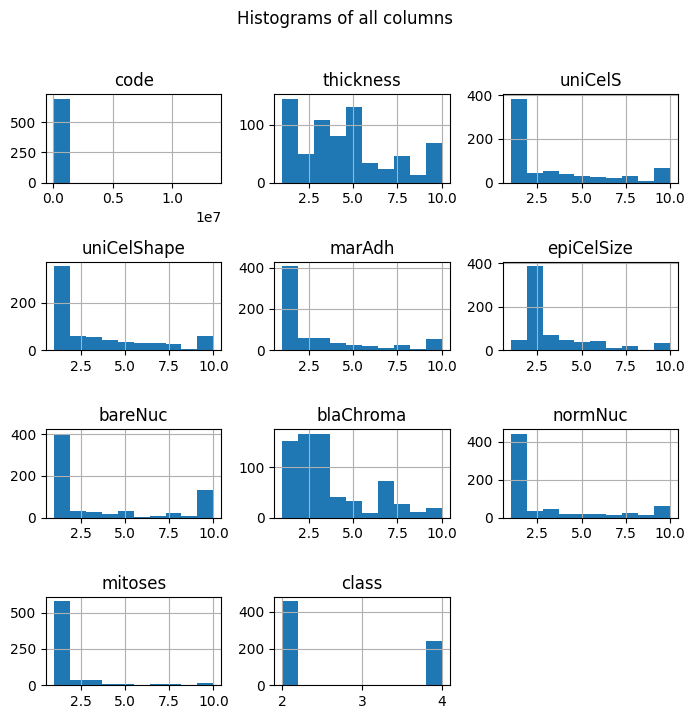

In [10]:
for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

# Histograms
df.hist(figsize=(7, 7))
plt.suptitle('Histograms of all columns', y=1.02)
plt.tight_layout()
plt.plot()


We chose the median as our imputation method. To understand this decision, it is useful to compare it with other approaches such as the mean and the mode.

Mean imputation replaces missing values with the arithmetic average. However, the main limitation of the mean is its sensitivity to outliers and skewed distributions. Since our variables show biased (skewed) distributions, as observed in the histograms, the mean can be strongly affected by extreme values and may not represent the central tendency of the data accurately.

Mode imputation replaces missing values with the most frequent value. While this preserves integer values, it can introduce bias when one value dominates the dataset, as it may not reflect the overall distribution of the data.

In contrast, the median represents the middle value of the ordered dataset and is robust to outliers. Even though it may occasionally result in a non-integer value when the number of observations is even, this is not an issue for imputation, as it provides a more stable and representative measure of central tendency for skewed or ordinal data. Based on the histograms, most variables show biased distributions, making the median a more appropriate choice than the mean.

In [23]:
print("Missing values before imputation:")
print(df.isnull().sum().to_string())

# We separate the features and the target
# Column 1 is Sample code number (ID), last column is Class.
features = df.columns[1:-1]
X = df[features]
y = df[df.columns[-1]]

# Apply median imputation
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features)
print("\nMissing values after imputation:")
print(X_imputed.isnull().sum().to_string())

Missing values before imputation:
code            0
thickness       0
uniCelS         0
uniCelShape     0
marAdh          0
epiCelSize      0
bareNuc        16
blaChroma       0
normNuc         0
mitoses         0
class           0

Missing values after imputation:
thickness      0
uniCelS        0
uniCelShape    0
marAdh         0
epiCelSize     0
bareNuc        0
blaChroma      0
normNuc        0
mitoses        0


### **b) PCA and Explained Variance**

Now we perform PCA. We only use the 9 numerical features. We also standardize the data so all features have equal scale. Then we plot the cumulative explained variance to see how many components we need to cover $\ge 90\%$ variance.

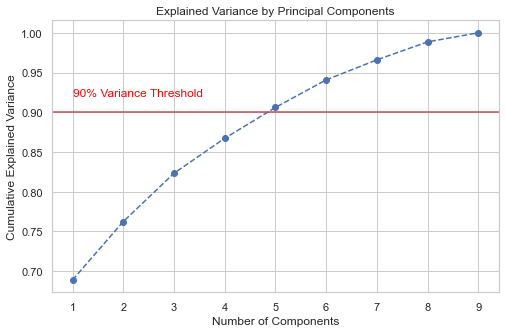

We need 5 components to cover >= 90% of the overall variance.


In [27]:
# Run PCA
pca = PCA()
pca.fit(X_imputed)

# Calculate cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Setting a nice style for plots
sns.set_theme(style="whitegrid")

# Plot the cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(1, 0.92, '90% Variance Threshold', color='red')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.xticks(range(1, 10))
plt.show()

# Find how many components are needed for >= 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"We need {n_components_90} components to cover >= 90% of the overall variance.")

To summarize what we just did in simple terms: We started with 9 different features describing a tumor (like cell size, shape, etc.). PCA is a mathematical way to compress this data. It creates new, combined features called 'principal components'. The graph above shows how much of the original information (variance) is captured by these new components.

The result tells us that instead of using all 9 original features, we can just use the first 6 components and still keep over 90% of the total information. This simplifies our dataset while keeping the most important patterns intact.

### **c) Scatter Plot Matrix for First 5 Components**

Here we plot the first 5 principal components against each other. We use different colors for Benign and Malignant classes. On the diagonal, we put density plots to see how well each component separates the classes.

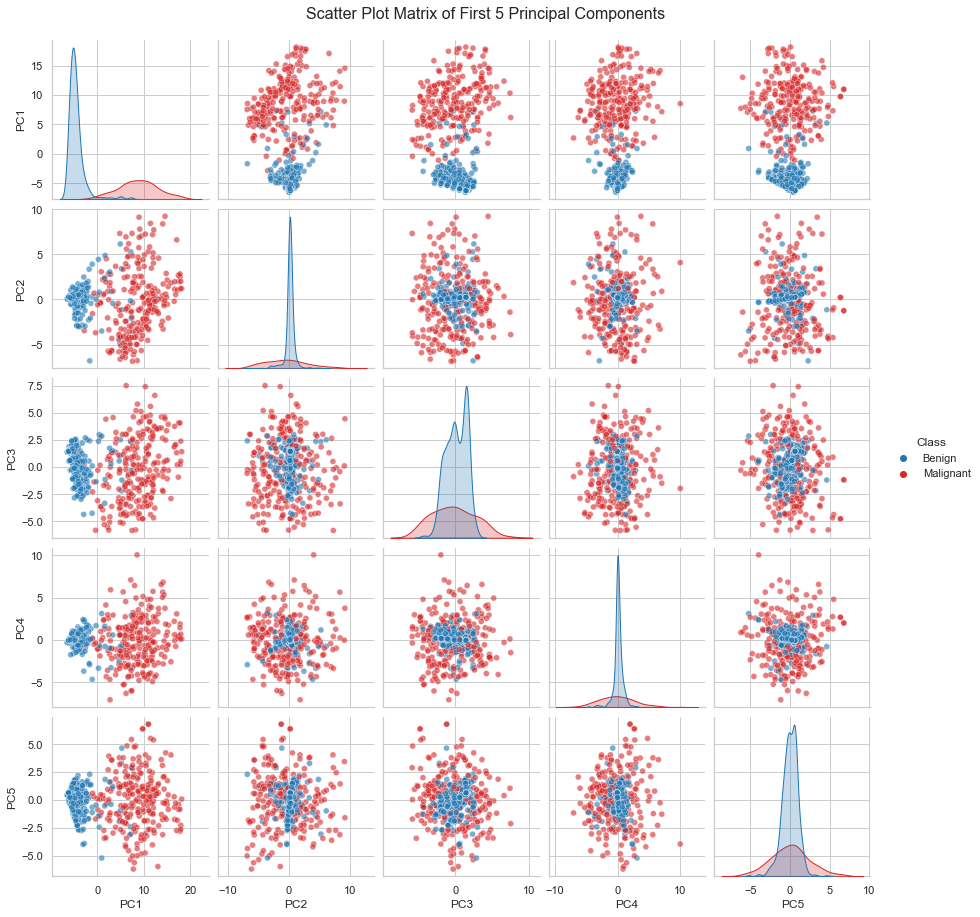

In [29]:
# Transform data using PCA
X_pca = pca.transform(X_imputed)

# Create a DataFrame for the first 5 components and the class
pca_df = pd.DataFrame(X_pca[:, :5], columns=[f'PC{i+1}' for i in range(5)])

# Map class 2 to 'Benign' and 4 to 'Malignant' for a clear legend
class_names = y.map({2: 'Benign', 4: 'Malignant'})
pca_df['Class'] = class_names.values

# Plot the scatter matrix using seaborn pairplot
sns.pairplot(pca_df, hue='Class', diag_kind='kde', 
             palette={'Benign': '#1f77b4', 'Malignant': '#d62728'},
             plot_kws={'alpha': 0.6})
plt.suptitle('Scatter Plot Matrix of First 5 Principal Components', y=1.02, fontsize=16)
plt.show()

### **d) Best PCA Mode for Separation**

Looking at the scatter plot matrix, the first principal component (PC1) shows the strongest difference between the Benign and Malignant classes. In the density plot for PC1 (top left corner), the two groups have very distinct peaks with little overlap.

Let's find which original variables have the highest and lowest weights in defining PC1.

In [ ]:
# The components are stored in pca.components_
pc1_weights = pca.components_[0]

# Create a Series to easily sort and view the weights
weights_series = pd.Series(pc1_weights, index=features)

print("Weights for PC1 definition:")
print(weights_series.sort_values(ascending=False).to_string())

# Absolute weights show the overall influence (positive or negative)
abs_weights = weights_series.abs().sort_values(ascending=False)

highest_weight_var = abs_weights.index[0]
lowest_weight_var = abs_weights.index[-1]

print(f"\nOriginal variable with the HIGHEST weight in PC1: {highest_weight_var} ({abs_weights.iloc[0]:.4f})")
print(f"Original variable with the LOWEST weight in PC1: {lowest_weight_var} ({abs_weights.iloc[-1]:.4f})")

Weights for PC1 definition:
uniCelS        0.381190
uniCelShape    0.377574
blaChroma      0.345956
epiCelSize     0.336391
normNuc        0.335840
bareNuc        0.333497
marAdh         0.332823
thickness      0.302805
mitoses        0.229818

Original variable with the HIGHEST weight in PC1: uniCelS (0.3812)
Original variable with the LOWEST weight in PC1: mitoses (0.2298)


To summarize what we found here: We already saw that PC1 is the best component for separating benign and malignant tumors. In this step, we looked "inside" PC1 to see how it was built. The weights tell us how much each of the original 9 features contributes to this specific principal component.

The results show that uniCelS (Uniformity of Cell Size) has the highest weight. This means the uniformity of cell size is the most important original feature for distinguishing between benign and malignant tumors in this dataset. On the other hand, mitoses has the lowest weight, meaning it provides the weakest clue for this separation compared to the other features.

### **e) Effect of Different Data Ranges on PCA**

*Question*: If the variables of a dataset have very different ranges, for example one variable is in [1000, 2000] and another one is in [1, 5], how would this affect the PCA? Could it make sense to pre-process the data in such cases? Why and how?

*Answer*:

If variables have very different ranges, PCA will be heavily affected by the scale. PCA tries to find the directions with the maximum variance. A variable with a large range like [1000, 2000] naturally has a much larger variance compared to a variable in [1, 5]. 

Because of this, PCA will incorrectly think that the large-range variable is the most important one and will dominate the principal components. The small-range variable will be mostly ignored, even if it has very important patterns for separating the classes.

Yes, it makes a lot of sense to pre-process the data. We should use standardization.

How: We subtract the mean from each variable and divide by the standard deviation. This gives every variable a mean of 0 and a standard deviation of 1. 

Why: This puts all variables on an equal scale. After standardizing, PCA will find the real correlations and patterns between variables, instead of just choosing the ones with the biggest numbers.